In [7]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense

In [8]:
(X_train,y_train),(X_test,y_test)=fashion_mnist.load_data()

print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


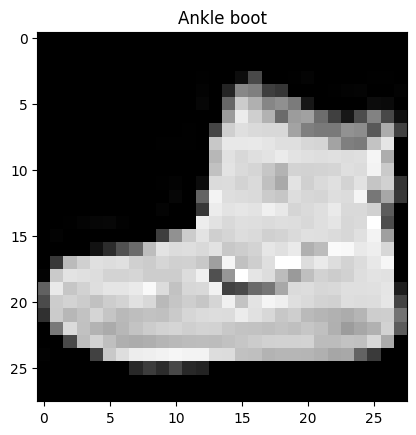

In [9]:
labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.imshow(X_train[0], cmap="gray")

plt.title(labels[y_train[0]])

plt.show()

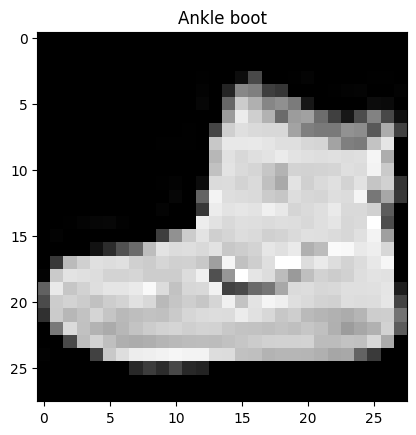

In [10]:
labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

plt.imshow(X_train[0], cmap="gray")

plt.title(labels[y_train[0]])

plt.show()

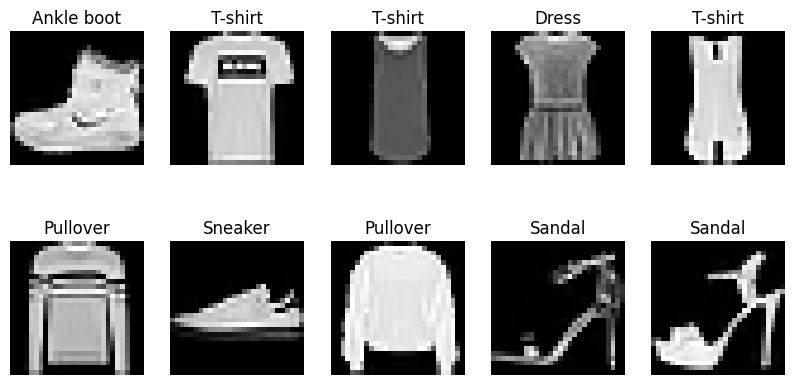

In [11]:
plt.figure(figsize=(10,5))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(labels[y_train[i]])

    plt.axis('off')

plt.show()

In [13]:
X_train = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_test = X_test.reshape(
    -1,
    28,
    28,
    1
)

print(X_train.shape)

(60000, 28, 28, 1)


In [14]:
X_train = X_train / 255.0

X_test = X_test / 255.0

In [15]:
y_train = to_categorical(
    y_train,
    10
)

y_test = to_categorical(
    y_test,
    10
)

In [16]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(28,28,1)
    )
)

model.add(
    MaxPooling2D(
        (2,2)
    )
)

model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(
    MaxPooling2D(
        (2,2)
    )
)

model.add(
    Flatten()
)

model.add(
    Dense(
        128,
        activation='relu'
    )
)

model.add(
    Dense(
        10,
        activation='softmax'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 136ms/step - accuracy: 0.8040 - loss: 0.5521 - val_accuracy: 0.8585 - val_loss: 0.3906
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 68s 103ms/step - accuracy: 0.8711 - loss: 0.3571 - val_accuracy: 0.8703 - val_loss: 0.3591
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.8859 - loss: 0.3106 - val_accuracy: 0.8877 - val_loss: 0.3063
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 82s 101ms/step - accuracy: 0.8976 - loss: 0.2807 - val_accuracy: 0.8927 - val_loss: 0.2974
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 44s 104ms/step - accuracy: 0.9045 - loss: 0.2572 - val_accuracy: 0.8975 - val_loss: 0.2804
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9120 - loss: 0.2373 - val_accuracy: 0.9003 - val_loss: 0.2701
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 83s 102ms/step - accuracy: 0.9195 - loss: 0.2189 - val_accuracy: 0.9087 - val_loss: 0.2551
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 101ms/step - accuracy: 0.9253 - loss: 0

In [20]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Loss =", loss)

print("Accuracy =", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9072 - loss: 0.2562
Loss = 0.2561842203140259
Accuracy = 0.9071999788284302


In [21]:
pred = model.predict(X_test)

pred_class = np.argmax(
    pred,
    axis=1
)

real_class = np.argmax(
    y_test,
    axis=1
)

print("Predict :", pred_class[:10])

print("Real    :", real_class[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Predict : [9 2 1 1 6 1 4 6 5 7]
Real    : [9 2 1 1 6 1 4 6 5 7]


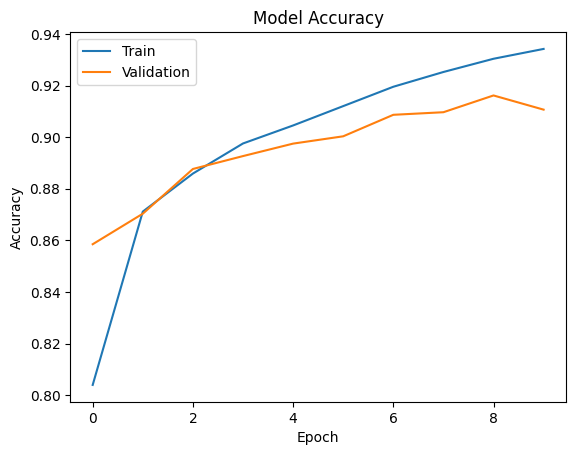

In [22]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(
    ['Train','Validation']
)

plt.show()

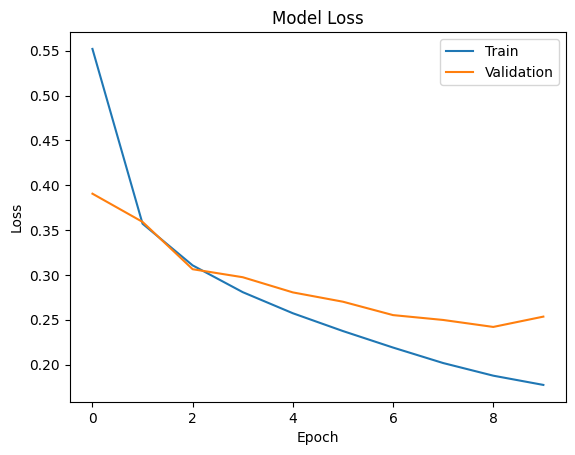

In [23]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(
    ['Train','Validation']
)

plt.show()

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    real_class,
    pred_class
)

print(cm)

[[837   0  20  19   2   1 114   0   7   0]
 [  2 977   0  15   1   0   3   0   2   0]
 [ 12   0 881  12  33   0  60   0   2   0]
 [ 10   2   7 941  11   0  27   0   2   0]
 [  2   1  71  48 804   0  72   0   2   0]
 [  0   0   0   0   0 960   0  28   0  12]
 [ 92   1  66  28  50   0 756   0   7   0]
 [  0   0   0   0   0   5   0 991   0   4]
 [  4   0   6   3   2   1   3   4 977   0]
 [  1   0   0   0   0   1   0  50   0 948]]


In [25]:
from sklearn.metrics import classification_report

print(
    classification_report(
        real_class,
        pred_class
    )
)

              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1000
           1       1.00      0.98      0.99      1000
           2       0.84      0.88      0.86      1000
           3       0.88      0.94      0.91      1000
           4       0.89      0.80      0.84      1000
           5       0.99      0.96      0.98      1000
           6       0.73      0.76      0.74      1000
           7       0.92      0.99      0.96      1000
           8       0.98      0.98      0.98      1000
           9       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000

